# Titanic Exploratory Data Analysis (EDA)

**Competition:** Kaggle - Titanic: Machine Learning from Disaster  
**Purpose:** Document the exploratory analysis used to understand data quality, variable distributions, and feature-survival relationships before modeling.


## 1. Import Libraries

Import the same libraries and reproducibility settings used in the project notebooks.


In [54]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization (optional for later EDA)
import matplotlib.pyplot as plt


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/"


## 2. Load Dataset

Load train and test datasets, then confirm input dimensions.


In [55]:
train_df = pd.read_csv(DATA_PATH + "train.csv")
test_df = pd.read_csv(DATA_PATH + "test.csv")
sample_submission = pd.read_csv(DATA_PATH + "gender_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (891, 12)
Test shape: (418, 11)
Sample submission shape: (418, 2)


## 3. Dataset Overview

Inspect the first rows of both datasets for a quick structural check.


In [56]:
print("\nFirst 5 rows of training data:")
display(train_df.head())

print("\nFirst 5 rows of test data:")
display(test_df.head())


First 5 rows of training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



First 5 rows of test data:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 4. Missing Values Analysis

Review schema information and inspect the columns with the highest missing-value counts.


In [57]:
train_df.info()

print("\nMissing values in training data:")
missing_train = train_df.isnull().sum().sort_values(ascending=False).head(5)
print(missing_train)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values in training data:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
dtype: int64


## 5. Data Distributions

Visualize the age distribution split by survival outcome.


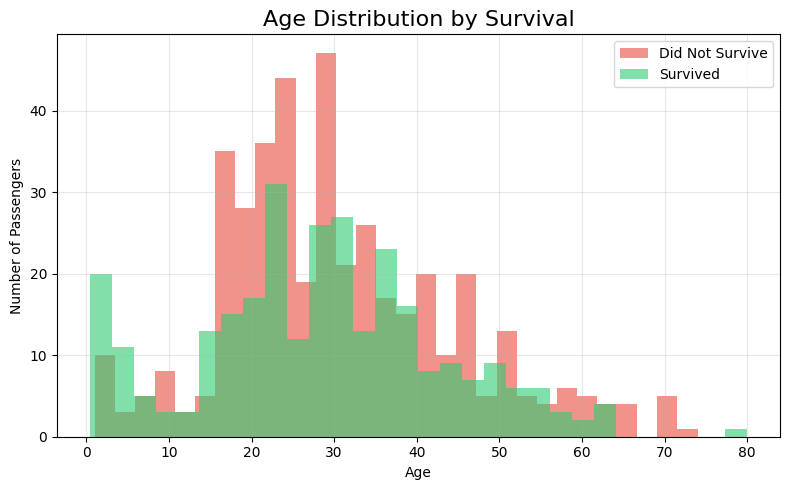

In [58]:
plt.figure(figsize=(8,5))

plt.hist(train_df[train_df["Survived"] == 0]["Age"].dropna(),
         bins=30,
         alpha=0.6,
         label="Did Not Survive",
         color="#e74c3c")

plt.hist(train_df[train_df["Survived"] == 1]["Age"].dropna(),
         bins=30,
         alpha=0.6,
         label="Survived",
         color="#2ecc71")

plt.title("Age Distribution by Survival", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

A dedicated correlation-matrix code cell was not present in the original notebook. To keep Python logic unchanged, no additional correlation computation is introduced here.


## 7. Feature Relationships

Explore how survival varies across core categorical and engineered grouping variables.


<Figure size 800x500 with 0 Axes>

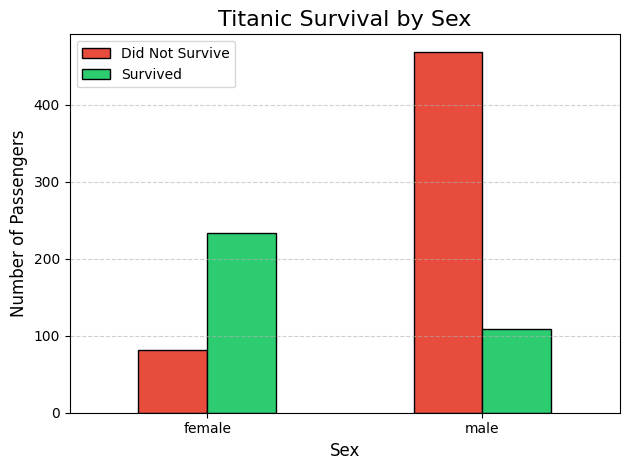

In [59]:
sex_survival = train_df.groupby(["Sex", "Survived"]).size().unstack()

plt.figure(figsize=(8,5))

sex_survival.plot(
    kind="bar",
    color=["#e74c3c", "#2ecc71"],   # red = died, green = survived
    edgecolor="black"
)

plt.title("Titanic Survival by Sex", fontsize=16)
plt.xlabel("Sex", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

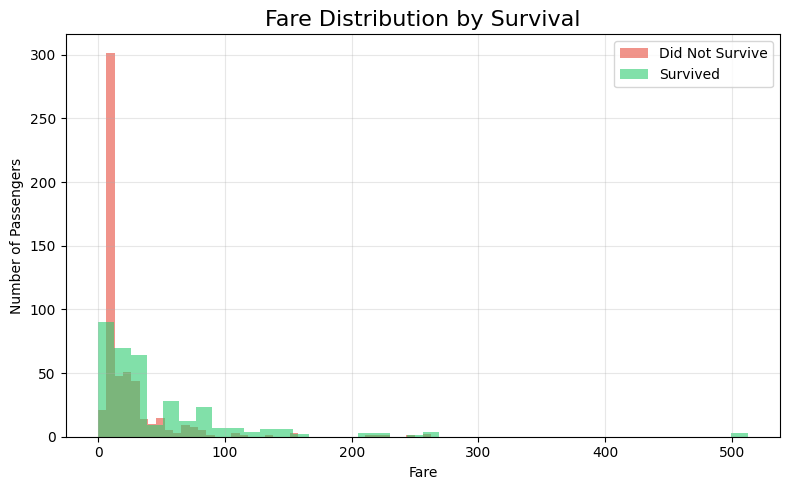

In [60]:
plt.figure(figsize=(8,5))

plt.hist(train_df[train_df["Survived"] == 0]["Fare"],
         bins=40,
         alpha=0.6,
         label="Did Not Survive",
         color="#e74c3c")

plt.hist(train_df[train_df["Survived"] == 1]["Fare"],
         bins=40,
         alpha=0.6,
         label="Survived",
         color="#2ecc71")

plt.title("Fare Distribution by Survival", fontsize=16)
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
